In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np 
df=pd.read_csv("mental_health.csv")
print(df.head())
print(df.info())
print(df.describe())


        Age  Gender Occupation        Days_Indoors Growing_Stress  \
0     20-25  Female  Corporate           1-14 days            Yes   
1  30-Above    Male     Others          31-60 days            Yes   
2  30-Above  Female    Student    Go out Every day             No   
3     25-30    Male     Others           1-14 days            Yes   
4     16-20  Female    Student  More than 2 months            Yes   

  Quarantine_Frustrations Changes_Habits Mental_Health_History Weight_Change  \
0                     Yes             No                   Yes           Yes   
1                     Yes          Maybe                    No            No   
2                      No            Yes                    No            No   
3                      No          Maybe                    No         Maybe   
4                     Yes            Yes                    No           Yes   

  Mood_Swings Coping_Struggles Work_Interest Social_Weakness  
0      Medium               No           

In [2]:
print("\nGrowing Stress distribution:")
print(df['Growing_Stress'].value_counts())



Growing Stress distribution:
Growing_Stress
Yes      301
Maybe    267
No       256
Name: count, dtype: int64


In [3]:
from sklearn.preprocessing import LabelEncoder
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicates:", df.duplicated().sum())

print("\nUnique values per columns:")
for col in df.columns:
    print(col, ":", df[col].unique())

le=LabelEncoder()
df_encoded=df.copy()

for col in df_encoded.columns:
    df_encoded[col]=le.fit_transform(df_encoded[col])
print("\nAfter encoding:")
print(df_encoded.head())

Missing values:
Age                        0
Gender                     0
Occupation                 0
Days_Indoors               0
Growing_Stress             0
Quarantine_Frustrations    0
Changes_Habits             0
Mental_Health_History      0
Weight_Change              0
Mood_Swings                0
Coping_Struggles           0
Work_Interest              0
Social_Weakness            0
dtype: int64

Duplicates: 0

Unique values per columns:
Age : ['20-25' '30-Above' '25-30' '16-20']
Gender : ['Female' 'Male']
Occupation : ['Corporate' 'Others' 'Student' 'Housewife' 'Business']
Days_Indoors : ['1-14 days' '31-60 days' 'Go out Every day' 'More than 2 months'
 '15-30 days']
Growing_Stress : ['Yes' 'No' 'Maybe']
Quarantine_Frustrations : ['Yes' 'No' 'Maybe']
Changes_Habits : ['No' 'Maybe' 'Yes']
Mental_Health_History : ['Yes' 'No' 'Maybe']
Weight_Change : ['Yes' 'No' 'Maybe']
Mood_Swings : ['Medium' 'High' 'Low']
Coping_Struggles : ['No' 'Yes']
Work_Interest : ['No' 'Maybe' 'Yes']
Soci

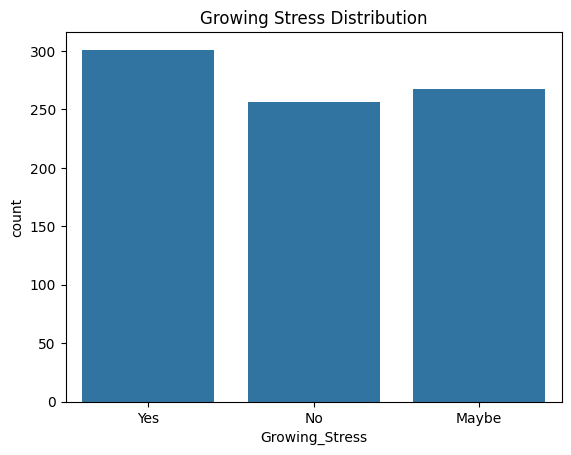

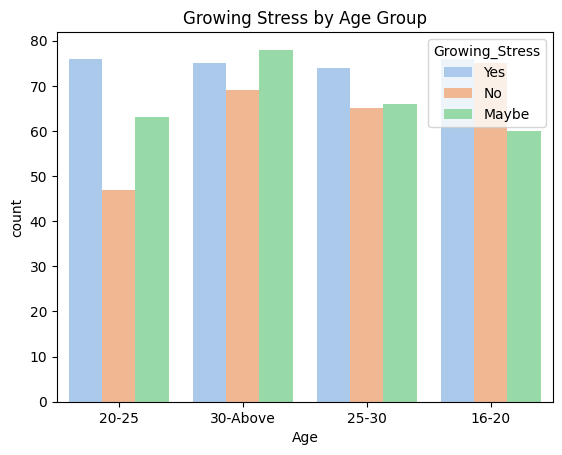

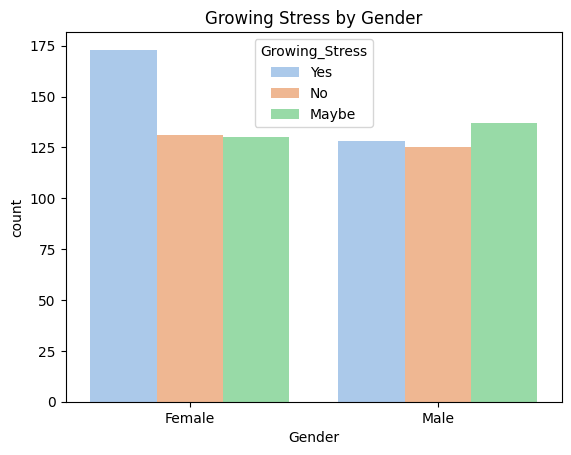

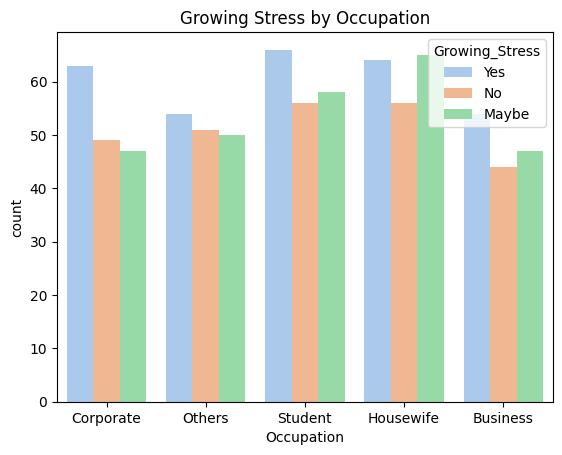

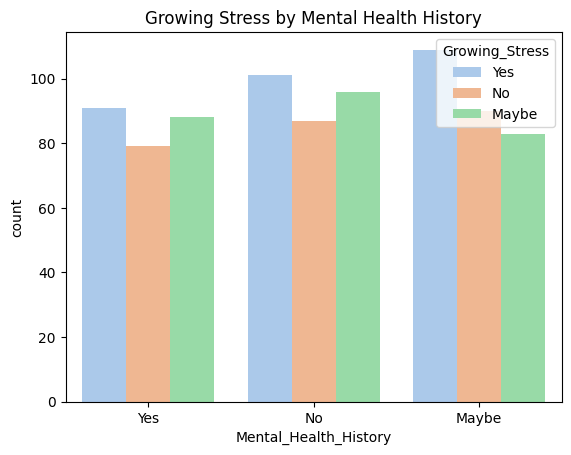

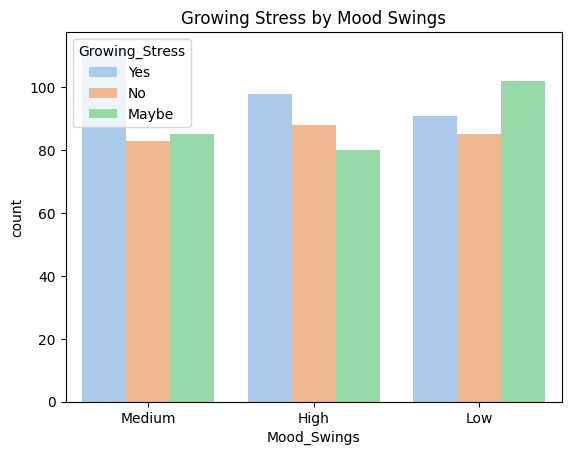

In [4]:
sns.countplot(x='Growing_Stress', data=df)
plt.title("Growing Stress Distribution")
plt.show()

sns.countplot(x='Age', hue='Growing_Stress', data=df, palette='pastel')
plt.title("Growing Stress by Age Group")
plt.show()

sns.countplot(x='Gender', hue='Growing_Stress', data=df, palette='pastel')
plt.title("Growing Stress by Gender")
plt.show()

sns.countplot(x='Occupation', hue='Growing_Stress', data=df, palette='pastel')
plt.title("Growing Stress by Occupation")
plt.show()

sns.countplot(x='Mental_Health_History', hue='Growing_Stress', data=df, palette='pastel')
plt.title("Growing Stress by Mental Health History")
plt.show()

sns.countplot(x='Mood_Swings', hue='Growing_Stress', data=df, palette='pastel')
plt.title("Growing Stress by Mood Swings")
plt.show()


In [5]:
print("Standart Deviation per column:")
print(df_encoded.std().sort_values(ascending=False))

Standart Deviation per column:
Days_Indoors               1.412899
Occupation                 1.398104
Age                        1.140857
Changes_Habits             0.833195
Quarantine_Frustrations    0.830938
Growing_Stress             0.829731
Weight_Change              0.816592
Mood_Swings                0.814333
Social_Weakness            0.813800
Mental_Health_History      0.809498
Work_Interest              0.800727
Coping_Struggles           0.500298
Gender                     0.499590
dtype: float64


Growing_Stress             1.000000
Quarantine_Frustrations    0.055394
Mood_Swings                0.015146
Work_Interest              0.006148
Coping_Struggles          -0.002686
Social_Weakness           -0.003319
Occupation                -0.013327
Weight_Change             -0.034904
Mental_Health_History     -0.039816
Age                       -0.041169
Days_Indoors              -0.058779
Gender                    -0.073551
Changes_Habits            -0.099350
Name: Growing_Stress, dtype: float64


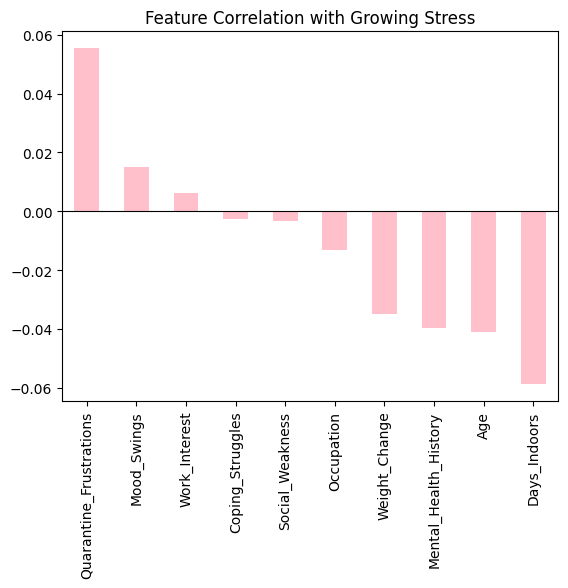

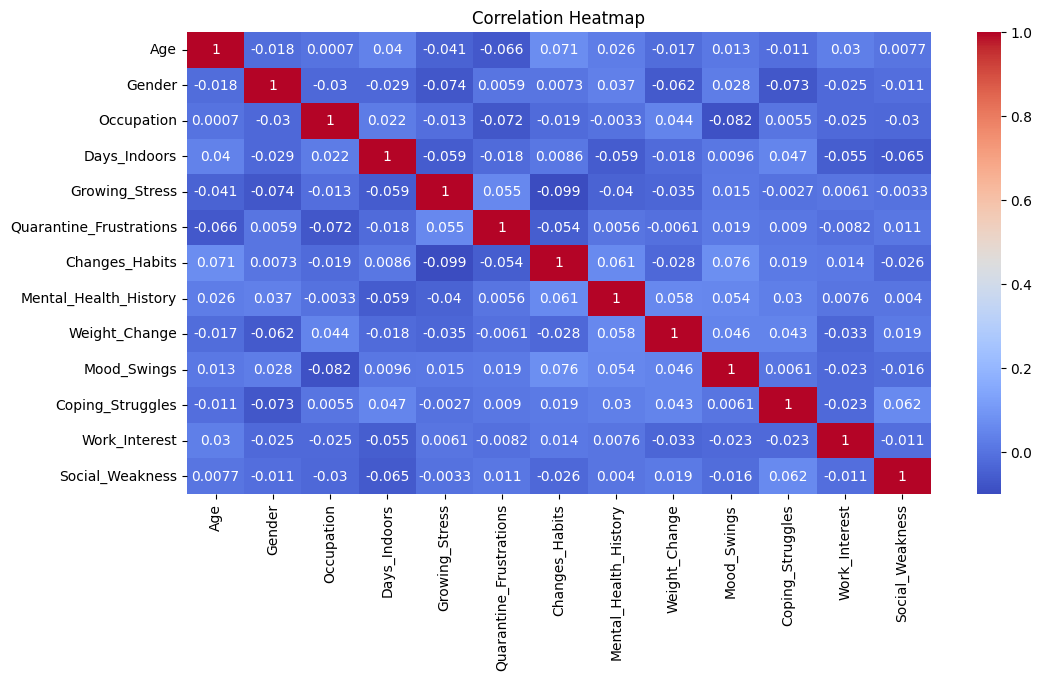

In [6]:
correlations=df_encoded.corr(numeric_only=True)['Growing_Stress'].sort_values(ascending=False)
print(correlations)

correlations.drop('Growing_Stress').head(10).plot(kind='bar', color='pink')
plt.title("Feature Correlation with Growing Stress")
plt.axhline(0, color='black', linewidth=0.8)
plt.show()

plt.figure(figsize=(12,6))
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

x=df_encoded.drop('Growing_Stress', axis=1)
y=df_encoded['Growing_Stress']

x_train, x_test, y_train, y_test=train_test_split(x, y, test_size=0.2, random_state=42)

model=RandomForestClassifier(random_state=42)
model.fit(x_train, y_train)

y_pred=model.predict(x_test)

print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.3212121212121212
              precision    recall  f1-score   support

           0       0.34      0.24      0.28        62
           1       0.28      0.19      0.23        52
           2       0.33      0.55      0.41        51

    accuracy                           0.32       165
   macro avg       0.32      0.33      0.31       165
weighted avg       0.32      0.32      0.31       165



Stress_Binary
1    568
0    256
Name: count, dtype: int64
Accuracy: 0.6606060606060606
              precision    recall  f1-score   support

           0       0.17      0.02      0.03        52
           1       0.68      0.96      0.79       113

    accuracy                           0.66       165
   macro avg       0.42      0.49      0.41       165
weighted avg       0.52      0.66      0.55       165



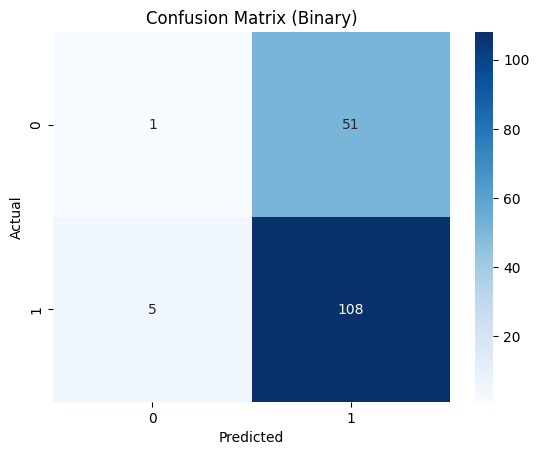

In [8]:
df['Stress_Binary']=df['Growing_Stress'].apply(lambda x: 0 if x== 'No' else 1)
print(df['Stress_Binary'].value_counts())

le=LabelEncoder()
df_binary=df.drop('Growing_Stress',axis=1).copy()
for col in df_binary.columns:
    if df_binary[col].dtype=='object':
        df_binary[col]=le.fit_transform(df_binary[col])
x=df_binary.drop('Stress_Binary', axis=1)
y=df_binary['Stress_Binary']

x_train, x_test, y_train, y_test=train_test_split(x, y, test_size=0.2, random_state=42)

model_binary=RandomForestClassifier(random_state=42)
model_binary.fit(x_train, y_train)

y_pred_binary=model_binary.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred_binary))
print(classification_report(y_test, y_pred_binary))

sns.heatmap(confusion_matrix(y_test, y_pred_binary), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (Binary)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Before SMOTE: {1: 455, 0: 204}
After SMOTE: {1: 455, 0: 455}
Accuracy: 0.5818181818181818
              precision    recall  f1-score   support

           0       0.33      0.31      0.32        52
           1       0.69      0.71      0.70       113

    accuracy                           0.58       165
   macro avg       0.51      0.51      0.51       165
weighted avg       0.58      0.58      0.58       165



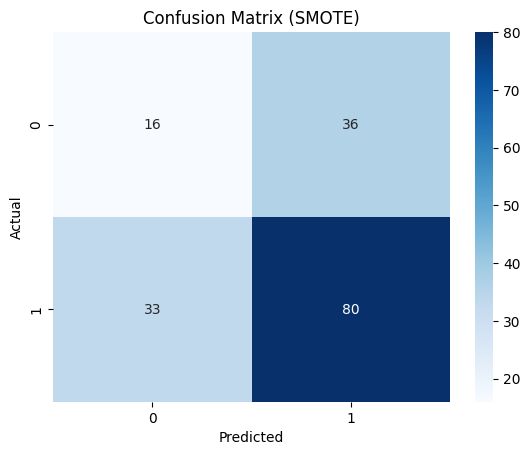

In [9]:
from imblearn.over_sampling import SMOTE 
smote=SMOTE(random_state=42)

x_train_smote, y_train_smote= smote.fit_resample(x_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_smote.value_counts().to_dict())

model_smote= RandomForestClassifier(random_state=42)
model_smote.fit(x_train_smote, y_train_smote)

y_pred_smote=model_smote.predict(x_test)
print("Accuracy:", accuracy_score(y_test, y_pred_smote))
print(classification_report(y_test, y_pred_smote))

sns.heatmap(confusion_matrix(y_test, y_pred_smote), annot=True, fmt='d',cmap='Blues' )
plt.title('Confusion Matrix (SMOTE)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Accuracy: 0.6848484848484848
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        52
           1       0.68      1.00      0.81       113

    accuracy                           0.68       165
   macro avg       0.34      0.50      0.41       165
weighted avg       0.47      0.68      0.56       165



C:\Users\User\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\User\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\User\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize

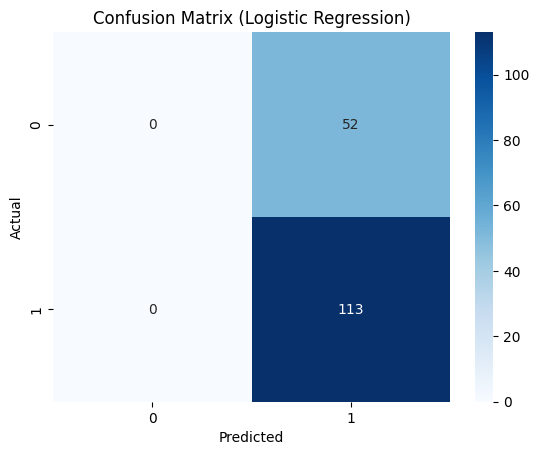

In [10]:
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression(random_state=42, max_iter=1000)

model_lr.fit(x_train, y_train)

y_pred_lr = model_lr.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (Logistic Regression)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show() 


Before SMOTE: {1: 455, 0: 204}
After SMOTE: {1: 455, 0: 455}
Accuracy: 0.5212121212121212
              precision    recall  f1-score   support

           0       0.33      0.50      0.40        52
           1       0.70      0.53      0.60       113

    accuracy                           0.52       165
   macro avg       0.51      0.52      0.50       165
weighted avg       0.58      0.52      0.54       165



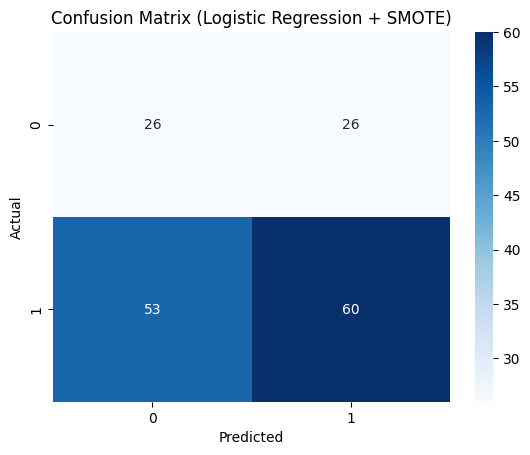

In [13]:
from imblearn.over_sampling import SMOTE
smote=SMOTE(random_state=42)

x_train_smote, y_train_smote=smote.fit_resample(x_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_smote.value_counts().to_dict())

model_lr_smote=LogisticRegression(random_state=42, max_iter=1000)
model_lr_smote.fit(x_train_smote, y_train_smote)

y_pred_lr_smote=model_smote.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred_lr_smote))
print(classification_report(y_test, y_pred_lr_smote, zero_division=0))

sns.heatmap(confusion_matrix(y_test, y_pred_lr_smote), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (Logistic Regression + SMOTE)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()